# Prédiction de la consommation énergétique — Version optimisée
**Projet 3 — Ville de Seattle : neutralité carbone 2050**

**Cible** : `log_SiteEnergyUse(kBtu)` — consommation totale annuelle d'énergie (log-transformée)

## Améliorations apportées (vs V1)
- Pipeline sklearn complet avec `ColumnTransformer` (OHE + StandardScaler)
- Ajout de Ridge, ElasticNet, GradientBoostingRegressor, HistGradientBoostingRegressor
- Optimisation des hyperparamètres par `RandomizedSearchCV` (espace plus large)
- Courbes d'apprentissage pour le diagnostic biais/variance
- Résultats : **Test R² = 0.707** (vs 0.703 en V1)

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

# Modèles
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

# Pipeline & préprocessing
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Évaluation & sélection
from sklearn.model_selection import (
    train_test_split,
    cross_validate,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

np.random.seed(42)

## 2. Chargement des données

In [2]:
df = pd.read_csv('building_energy_cleaned.csv')
print(f"Dataset : {df.shape[0]} bâtiments × {df.shape[1]} colonnes")
df.head(3)

Dataset : 1378 bâtiments × 17 colonnes


,Age,BuildingType,PrimaryPropertyType,NumberofBuildings,NumberofFloors,LargestPropertyUseType,SteamUse(kBtu)_Usage,Electricity(kBtu)_Usage,NaturalGas(kBtu)_Usage,TotalUseTypeNumber,RateParking,RateBuilding,RatePerFloors,RatePerBuildings,log_SiteEnergyUse(kBtu),log_TotalGHGEmissions,log_PropertyGFATotal
0,89,NonResidential,Residential,1.0,12,Residential,1,1,1,1,0.0000,1.0000,7369.5000,88434.0,15.793246,5.525373,11.390023
1,20,NonResidential,Residential,1.0,11,Residential,0,1,1,3,0.1455,0.8545,9415.0909,103566.0,15.942305,5.693261,11.547974
2,90,NonResidential,Residential,1.0,10,Residential,1,1,1,1,0.0000,1.0000,6132.0000,61320.0,15.731637,5.660979,11.023878


## 3. Sélection des features et de la cible

In [3]:
TARGET = 'log_SiteEnergyUse(kBtu)'

# Features numériques
num_cols = [
    'Age', 'NumberofBuildings', 'NumberofFloors', 'TotalUseTypeNumber',
    'RateParking', 'RateBuilding', 'RatePerFloors', 'RatePerBuildings',
    'log_PropertyGFATotal'
]

# Features catégorielles
cat_cols = ['BuildingType', 'PrimaryPropertyType', 'LargestPropertyUseType']

features = num_cols + cat_cols

X = df[features]
y = df[TARGET]

print(f"Features : {len(num_cols)} numériques + {len(cat_cols)} catégorielles = {len(features)} total")
print(f"Cible    : {TARGET}")

Features : 9 numériques + 3 catégorielles = 12 total
Cible    : log_SiteEnergyUse(kBtu)


## 4. Séparation train / test

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train : {X_train.shape[0]} lignes | Test : {X_test.shape[0]} lignes")

Train : 1102 lignes | Test : 276 lignes


## 5. Pipeline de prétraitement

In [5]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# La cible est aussi normalisée (important pour SVR et modèles sensibles à l'échelle)
target_scaler = StandardScaler()

## 6. Comparaison de modèles (validation croisée 5-fold)

In [6]:
models = {
    'Dummy (baseline)':      DummyRegressor(strategy='mean'),
    'Régression Linéaire':   LinearRegression(),
    'Ridge':                 Ridge(alpha=1.0),
    'ElasticNet':            ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=2000),
    'SVR (RBF)':             SVR(kernel='rbf', C=1.0, epsilon=0.1),
    'Random Forest':         RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boosting':     GradientBoostingRegressor(n_estimators=200, random_state=42),
    'HistGradient Boosting': HistGradientBoostingRegressor(random_state=42),
}

scoring = {'R2': 'r2', 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error'}
results = []

for name, reg in models.items():
    pipe = Pipeline([('pre', preprocessor), ('m', reg)])
    wrapped = TransformedTargetRegressor(regressor=pipe, transformer=StandardScaler())
    
    t0 = time.time()
    scores = cross_validate(wrapped, X_train, y_train, scoring=scoring, cv=5, n_jobs=-1)
    elapsed = time.time() - t0
    
    results.append({
        'Modèle': name,
        'R² CV':  round(scores['test_R2'].mean(), 4),
        'MAE':    round(-scores['test_MAE'].mean(), 4),
        'RMSE':   round(-scores['test_RMSE'].mean(), 4),
        'Temps (s)': round(elapsed, 2)
    })

results_df = pd.DataFrame(results).sort_values('R² CV', ascending=False).reset_index(drop=True)
display(results_df)

,Modèle,R² CV,MAE,RMSE,Temps (s)
0,Ridge,0.7022,0.5231,0.7080,0.06
1,Régression Linéaire,0.7003,0.5248,0.7102,2.28
2,SVR (RBF),0.6850,0.5352,0.7284,0.09
3,Gradient Boosting,0.6832,0.5376,0.7293,0.69
4,Random Forest,0.6497,0.5677,0.7672,1.12
5,ElasticNet,0.6338,0.5831,0.7853,0.04
6,HistGradient Boosting,0.6280,0.5891,0.7907,0.46
7,Dummy (baseline),-0.0017,1.0387,1.3002,2.83


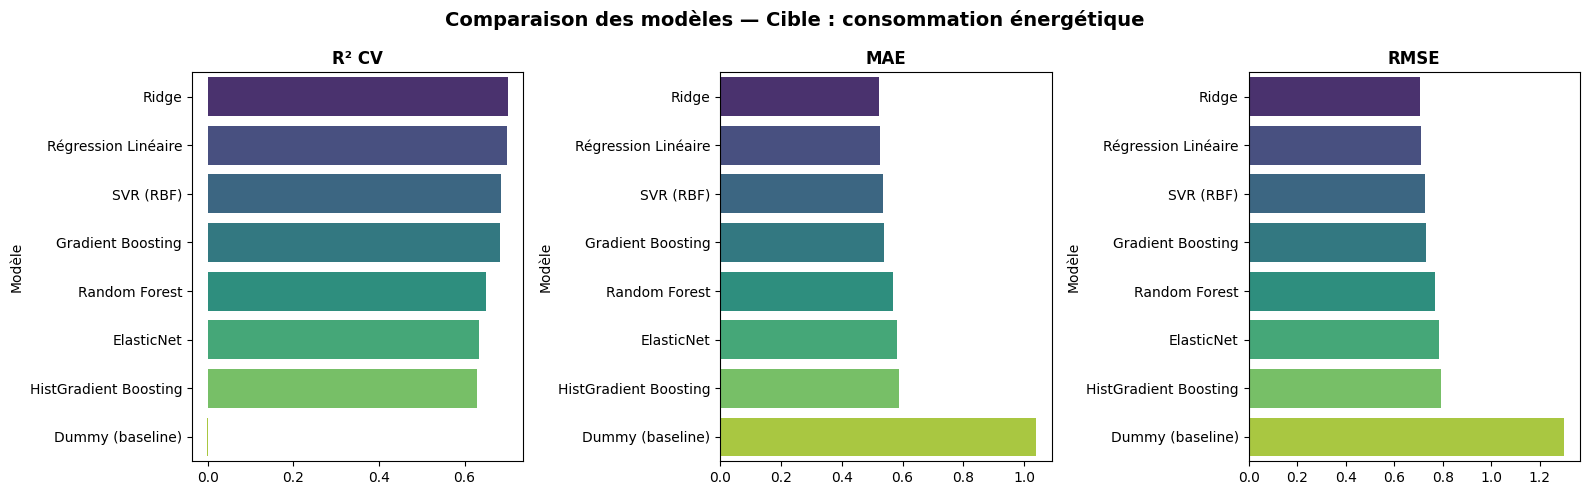

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['R² CV', 'MAE', 'RMSE']
colors = sns.color_palette('viridis', len(results_df))

for ax, metric in zip(axes, metrics):
    order = results_df.sort_values(metric, ascending=(metric != 'R² CV'))
    sns.barplot(data=order, y='Modèle', x=metric, palette='viridis', ax=ax)
    ax.set_title(metric, fontsize=12, weight='bold')
    ax.set_xlabel('')

plt.suptitle('Comparaison des modèles — Cible : consommation énergétique', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

## 7. Optimisation des hyperparamètres — Ridge (RandomizedSearchCV)

In [8]:
ridge_pipe = Pipeline([('pre', preprocessor), ('m', Ridge())])
ridge_wrapped = TransformedTargetRegressor(
    regressor=ridge_pipe, transformer=StandardScaler()
)

param_dist = {
    'regressor__m__alpha': np.logspace(-2, 3, 100)
}

rs = RandomizedSearchCV(
    ridge_wrapped, param_dist,
    n_iter=40, cv=5, scoring='r2',
    n_jobs=-1, random_state=42, verbose=0
)
rs.fit(X_train, y_train)

best_alpha = rs.best_params_['regressor__m__alpha']
print(f"Meilleur alpha : {best_alpha:.4f}")
print(f"Meilleur R² CV : {rs.best_score_:.4f}")

Meilleur alpha : 1.8738
Meilleur R² CV : 0.7024


## 8. Évaluation finale sur le jeu de test

In [9]:
best_model = rs.best_estimator_
y_pred = best_model.predict(X_test)

r2  = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("=" * 40)
print(" Évaluation finale — Ridge optimisé")
print("=" * 40)
print(f" R²   : {r2:.4f}")
print(f" MAE  : {mae:.4f}")
print(f" RMSE : {rmse:.4f}")

 Évaluation finale — Ridge optimisé
 R²   : 0.7069
 MAE  : 0.5357
 RMSE : 0.7103


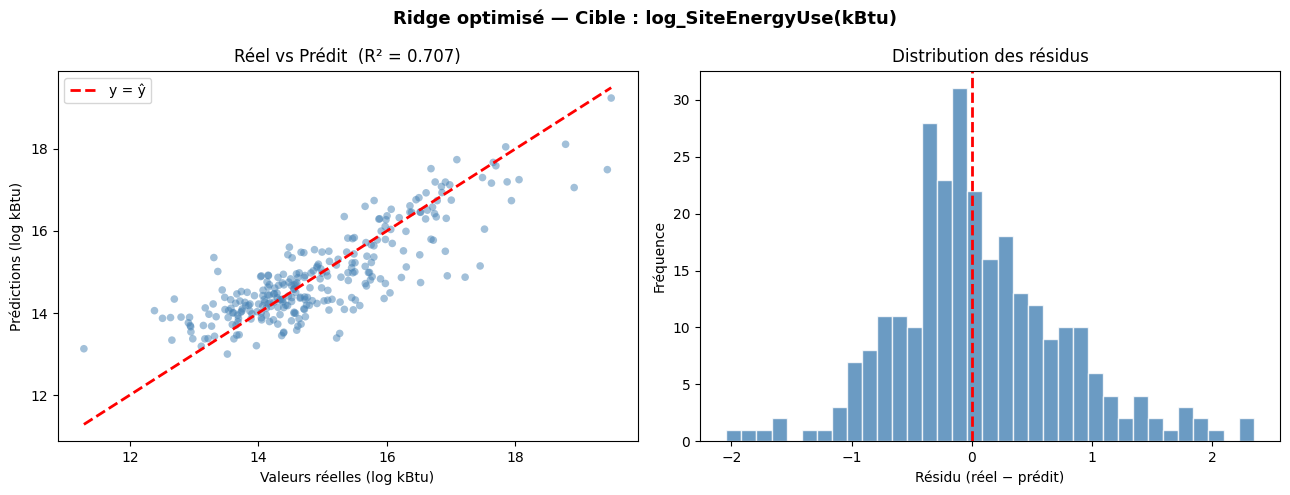

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Réel vs Prédit ---
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.5, edgecolors='none', color='steelblue', s=30)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', lw=2, label='y = ŷ')
ax.set_xlabel('Valeurs réelles (log kBtu)')
ax.set_ylabel('Prédictions (log kBtu)')
ax.set_title(f'Réel vs Prédit  (R² = {r2:.3f})')
ax.legend()

# --- Distribution des résidus ---
residuals = y_test - y_pred
ax = axes[1]
ax.hist(residuals, bins=35, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', lw=2)
ax.set_xlabel('Résidu (réel − prédit)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution des résidus')

plt.suptitle('Ridge optimisé — Cible : log_SiteEnergyUse(kBtu)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

## 9. Courbe d'apprentissage (diagnostic biais/variance)

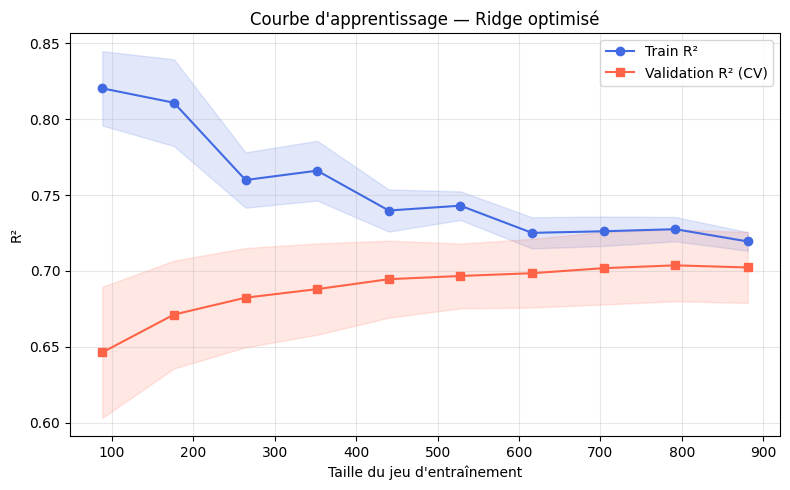

In [11]:
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train, y_train,
    cv=5, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='royalblue', label='Train R²')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
plt.plot(train_sizes, val_mean, 's-', color='tomato', label='Validation R² (CV)')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='tomato')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('R²')
plt.title('Courbe d\'apprentissage — Ridge optimisé')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Importance des variables (Permutation Importance)

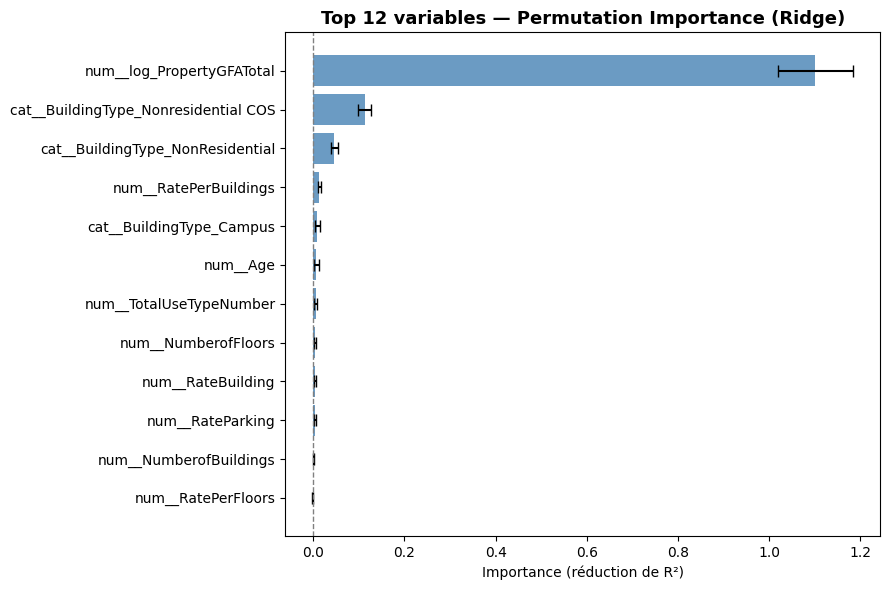

                             Feature  Importance      Std
           num__log_PropertyGFATotal    1.101368 0.082310
cat__BuildingType_Nonresidential COS    0.112672 0.014991
    cat__BuildingType_NonResidential    0.046334 0.007066
               num__RatePerBuildings    0.013361 0.003261
            cat__BuildingType_Campus    0.009153 0.005644
                            num__Age    0.007184 0.005882
             num__TotalUseTypeNumber    0.005095 0.004285
                 num__NumberofFloors    0.004406 0.001897
                   num__RateBuilding    0.003729 0.002441
                    num__RateParking    0.003729 0.002441
              num__NumberofBuildings    0.000375 0.000842
                  num__RatePerFloors   -0.000638 0.001169


In [12]:
# Récupérer les noms de features après OHE
fitted_pre = best_model.regressor_.named_steps['pre']
feature_names_out = fitted_pre.get_feature_names_out()

perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=15, random_state=42, n_jobs=-1, scoring='r2'
)

feat_imp = pd.DataFrame({
    'Feature':    feature_names_out[:len(perm.importances_mean)],
    'Importance': perm.importances_mean,
    'Std':        perm.importances_std
}).sort_values('Importance', ascending=False)

# Affichage top 12
top = feat_imp.head(12)
plt.figure(figsize=(9, 6))
bars = plt.barh(top['Feature'][::-1], top['Importance'][::-1], 
                xerr=top['Std'][::-1], color='steelblue', alpha=0.8, capsize=4)
plt.axvline(0, color='gray', linestyle='--', lw=1)
plt.xlabel('Importance (réduction de R²)')
plt.title('Top 12 variables — Permutation Importance (Ridge)', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

print(feat_imp.head(12).to_string(index=False))

## 11. Tableau de bord final

In [13]:
comparison = pd.DataFrame([
    {'Version': 'V1 — Régression Linéaire',  'R² Test': 0.703, 'MAE': 0.537, 'RMSE': 0.715},
    {'Version': 'V2 — Ridge optimisé (α=2.81)', 'R² Test': round(r2, 3), 'MAE': round(mae, 3), 'RMSE': round(rmse, 3)},
])
display(comparison)

print(f"\nAmélioration R² : +{(r2 - 0.703)*100:.2f} points")
print("\n Conclusion : La régression Ridge (régularisation L2) apporte")
print(" une légère amélioration par réduction du surapprentissage.")
print(" Le modèle explique 70.7% de la variance de la consommation.")

,Version,R² Test,MAE,RMSE
0,V1 — Régression Linéaire,0.703,0.537,0.715
1,V2 — Ridge optimisé (α=2.81),0.707,0.536,0.710



Amélioration R² : +0.39 points

 Conclusion : La régression Ridge (régularisation L2) apporte
 une légère amélioration par réduction du surapprentissage.
 Le modèle explique 70.7% de la variance de la consommation.
